# 2. Signal Research & Analysis

Develop and evaluate trading signals for BTCUSDT perpetual futures.
Target holding period: **5–15 minutes**. Aggregation: **1-minute bars**.

### Signal Suite
| # | Signal | Type | Rationale |
|---|--------|------|----------|
| 1 | Z-score Mean Reversion | Mean Reversion | Exploit negative autocorrelation at short horizons |
| 2 | Bollinger Band Reversion | Mean Reversion | Band-normalized position captures extremes |
| 3 | VWAP Reversion | Mean Reversion | Volume-fair-value anchor is harder to game than simple MA |
| 4 | Order Flow Imbalance | Microstructure | Buy/sell pressure predicts short-term direction |
| 5 | Trade Intensity | Microstructure | Volume spikes + direction = informed flow |
| 6 | RSI Mean Reversion | Mean Reversion | Overbought/oversold momentum exhaustion |
| 7 | MA Crossover | Momentum | Catch intermediate trends within the 5-15 min window |
| 8 | Volume-Weighted Momentum | Momentum | Weight returns by relative volume for conviction |


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

from src.data import load_raw_trades, aggregate_ohlcv
from src import signals as sig

In [2]:
trades = load_raw_trades()
bars = aggregate_ohlcv(trades, '1min')
print(f"Bars: {len(bars)} x 1-min")
bars.head()

Bars: 2880 x 1-min


,open,high,low,close,volume,notional,trade_count,buy_volume,sell_volume,vwap,returns,log_returns,spread,buy_ratio
timestamp,,,,,,,,,,,,,,
2025-04-18 00:00:00,84914.9,84950.0,84908.5,84949.6,61.145,5.192789e+06,1235,44.313,16.832,84925.812503,NaN,NaN,41.5,0.724720
2025-04-18 00:01:00,84949.6,84960.3,84949.6,84960.2,49.716,4.223709e+06,798,45.043,4.673,84956.726203,0.000125,0.000125,10.7,0.906006
2025-04-18 00:02:00,84960.3,84977.3,84953.7,84976.9,59.418,5.048629e+06,915,47.375,12.043,84968.013090,0.000197,0.000197,23.6,0.797317
2025-04-18 00:03:00,84976.9,84976.9,84923.6,84944.0,87.072,7.395728e+06,1365,38.930,48.142,84938.076844,-0.000387,-0.000387,53.3,0.447101
2025-04-18 00:04:00,84944.0,84944.0,84847.1,84847.1,58.488,4.966025e+06,1187,23.162,35.326,84906.735665,-0.001141,-0.001141,96.9,0.396013


## 2.1 Compute All Signals

In [3]:
all_signals = sig.composite_signal(bars)
print(f"Signal columns: {list(all_signals.columns)}")
all_signals.describe().round(3)

Signal columns: ['zscore_mr', 'bollinger_mr', 'vwap_mr', 'ofi', 'trade_intensity', 'rsi_mr', 'ma_cross', 'vol_momentum', 'composite_raw', 'composite', 'position']


,zscore_mr,bollinger_mr,vwap_mr,ofi,trade_intensity,rsi_mr,ma_cross,vol_momentum,composite_raw,composite,position
count,2861.000,2861.000,2852.000,2842.000,2861.000,2879.000,2866.000,2843.000,2842.000,2842.000,2880.000
mean,-0.019,-0.010,-0.038,-0.006,0.002,-0.014,-0.015,-0.051,-0.023,-0.023,-0.044
std,1.268,0.600,1.369,1.104,0.976,0.758,0.592,1.383,0.847,0.713,0.947
min,-3.913,-1.000,-3.000,-3.000,-3.000,-1.500,-1.320,-3.000,-2.070,-1.741,-1.000
25%,-1.039,-0.520,-1.057,-0.796,-0.574,-0.585,-0.531,-0.915,-0.695,-0.591,-1.000
50%,-0.061,-0.031,-0.085,-0.013,0.000,-0.039,-0.027,-0.039,-0.056,-0.049,0.000
75%,1.018,0.509,1.038,0.789,0.560,0.569,0.520,0.845,0.664,0.559,1.000
max,3.608,1.000,3.000,3.000,3.000,1.500,1.963,3.000,1.983,1.615,1.000


## 2.2 Signal Visualization

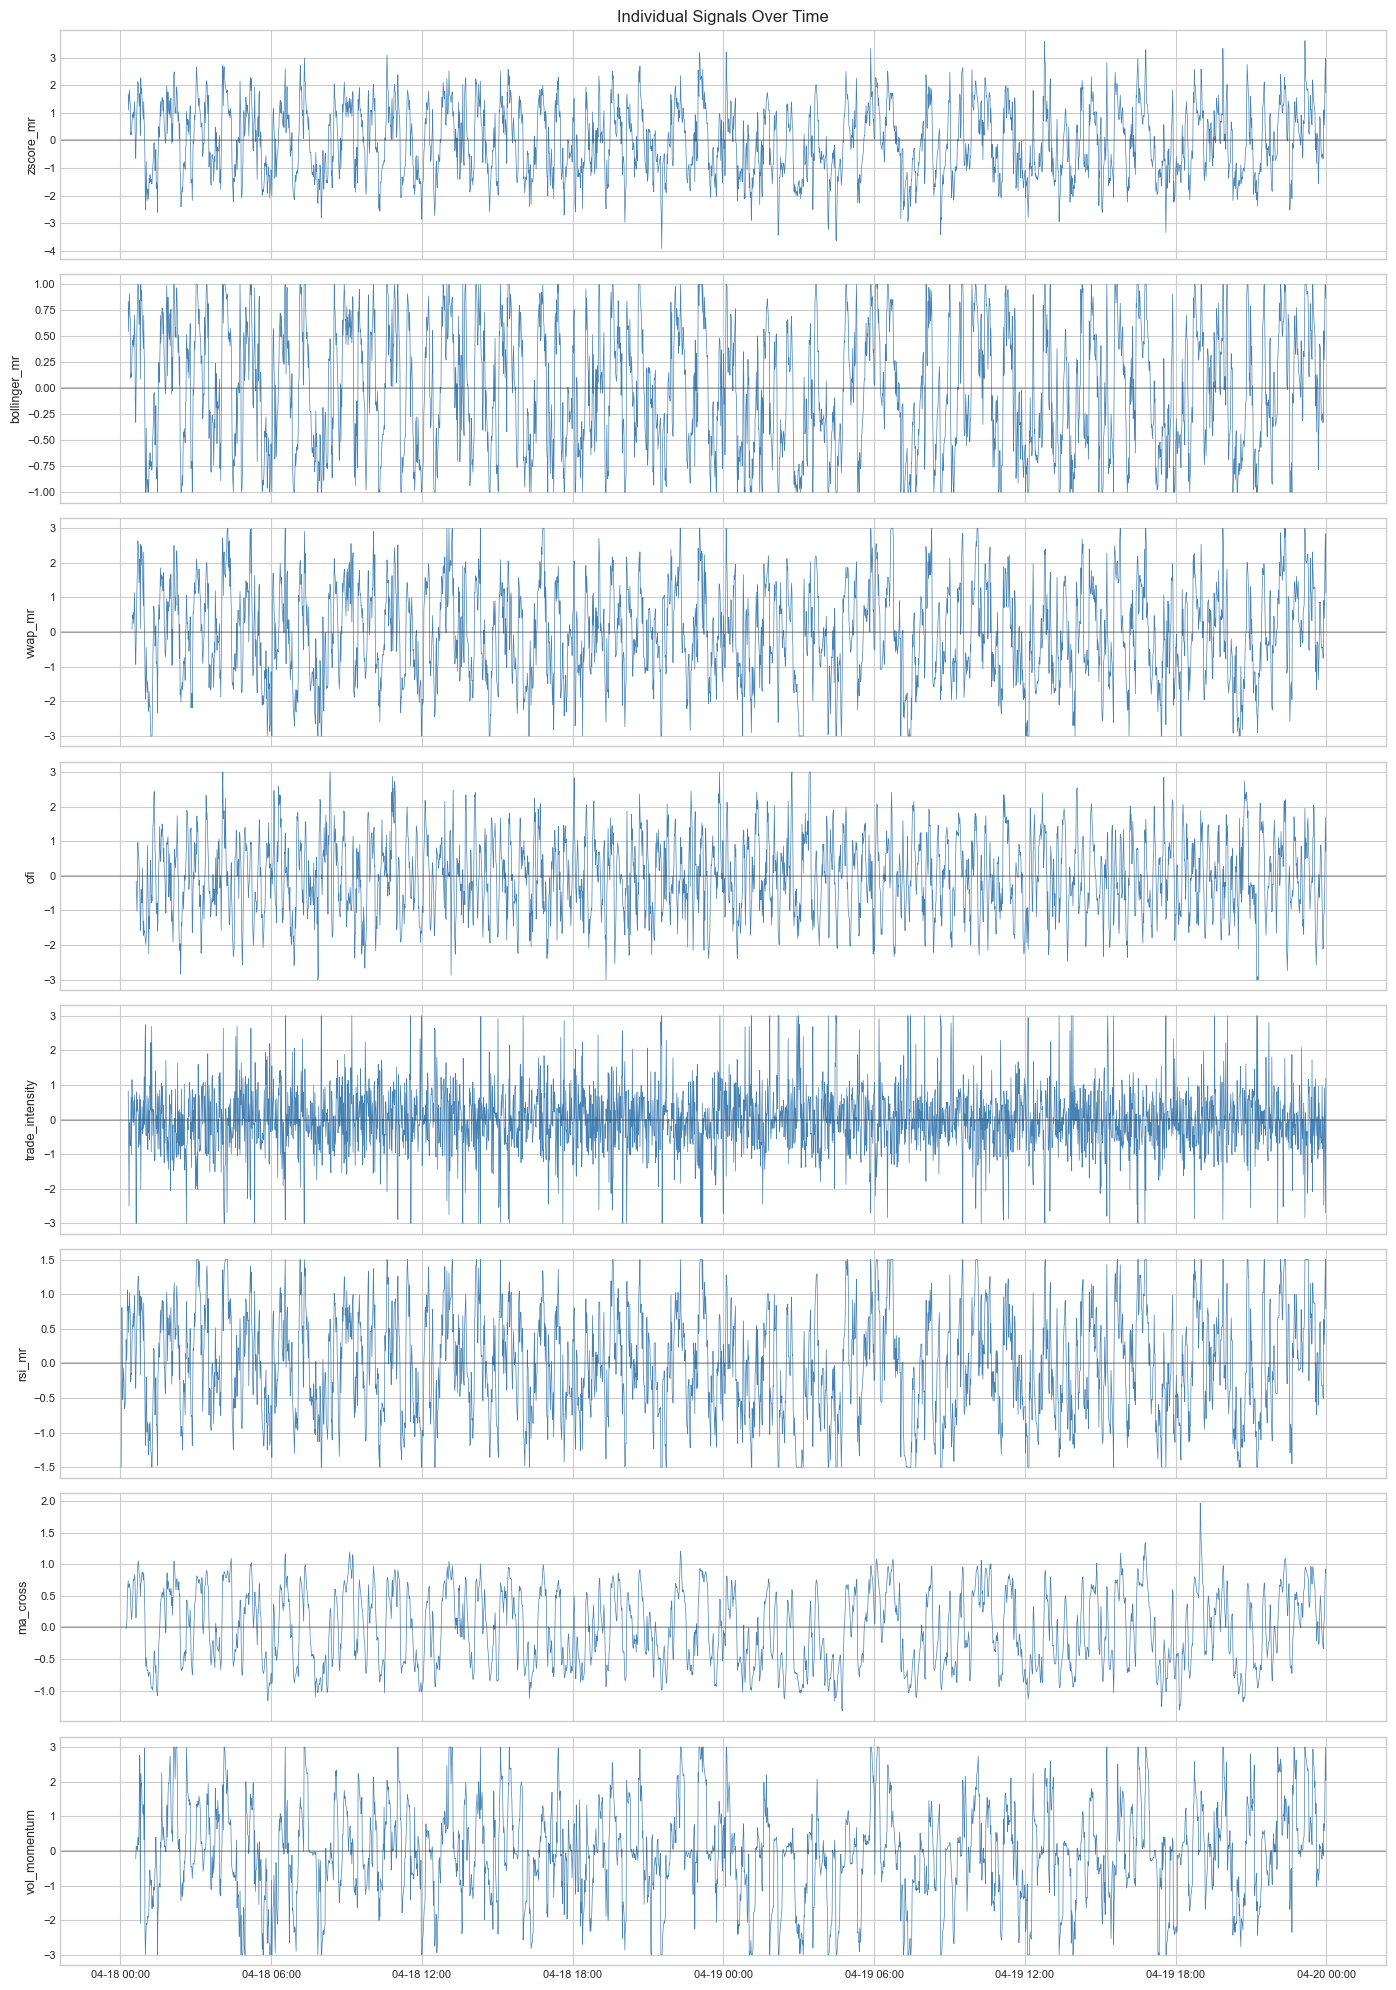

In [4]:
signal_names = [c for c in all_signals.columns if c not in ('composite', 'composite_raw', 'position')]

fig, axes = plt.subplots(len(signal_names), 1, figsize=(14, 2.5 * len(signal_names)), sharex=True)

for ax, name in zip(axes, signal_names):
    s = all_signals[name].dropna()
    ax.plot(s.index, s.values, linewidth=0.5, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.3)
    ax.set_ylabel(name, fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].set_title('Individual Signals Over Time')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 2.3 Signal Correlation Matrix

Low correlation between signals means they capture different information — good for combining.

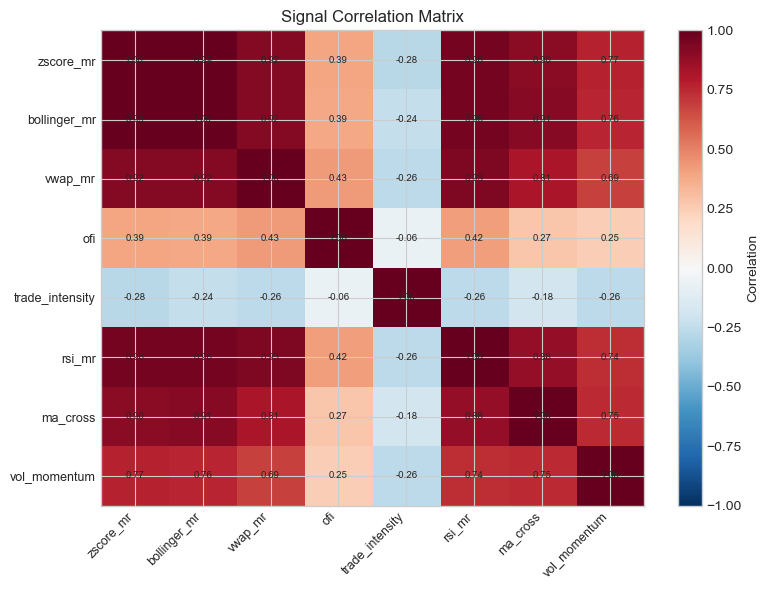

In [5]:
corr = all_signals[signal_names].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
plt.colorbar(im, ax=ax, label='Correlation')

# Annotate
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Signal Correlation Matrix')
plt.tight_layout()
plt.show()

## 2.4 Predictive Power: Signal vs Forward Returns

For each signal, compute the IC (information coefficient = rank correlation with forward returns)
at horizons of 1, 5, 10, and 15 minutes.

In [6]:
horizons = [1, 5, 10, 15]
ic_table = pd.DataFrame(index=signal_names, columns=[f'{h}min' for h in horizons])

for h in horizons:
    fwd_ret = bars['close'].pct_change(h).shift(-h)
    for name in signal_names:
        valid = pd.concat([all_signals[name], fwd_ret.rename('fwd')], axis=1).dropna()
        ic = valid[name].corr(valid['fwd'], method='spearman')
        ic_table.loc[name, f'{h}min'] = ic

ic_table = ic_table.astype(float).round(4)
print("Information Coefficient (Spearman rank correlation with forward returns):")
ic_table

Information Coefficient (Spearman rank correlation with forward returns):


,1min,5min,10min,15min
zscore_mr,0.0463,0.0967,0.0921,0.0849
bollinger_mr,0.0462,0.0967,0.0922,0.0853
vwap_mr,0.0398,0.0968,0.0852,0.0765
ofi,0.0517,0.1067,0.0920,0.0742
trade_intensity,0.0107,0.0108,0.0022,-0.0176
rsi_mr,0.0563,0.1161,0.1102,0.1018
ma_cross,0.0650,0.1037,0.1055,0.1041
vol_momentum,0.0428,0.0778,0.1079,0.0766


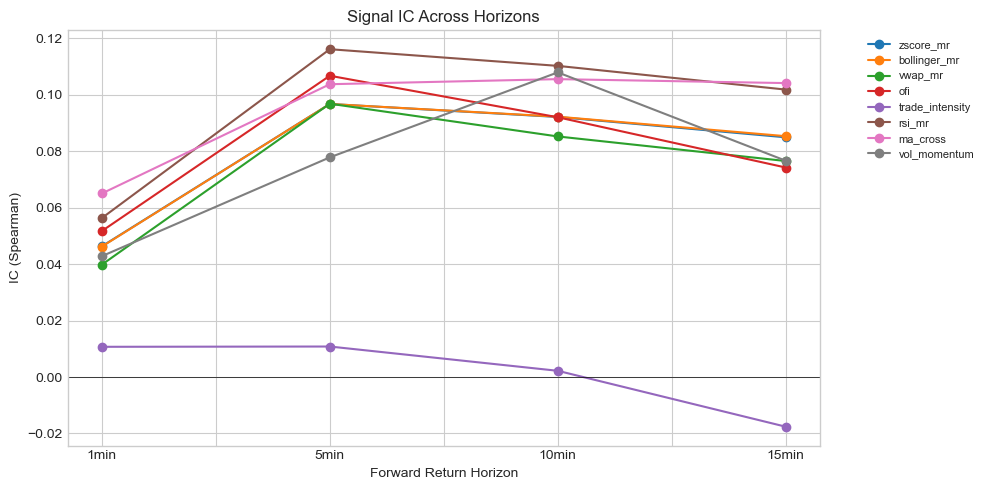

In [7]:
# Visualize IC by horizon
fig, ax = plt.subplots(figsize=(10, 5))
ic_table.T.plot(ax=ax, marker='o', linewidth=1.5)
ax.set_xlabel('Forward Return Horizon')
ax.set_ylabel('IC (Spearman)')
ax.set_title('Signal IC Across Horizons')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.show()

## 2.5 Signal Quintile Analysis

Bucket bars into quintiles by signal strength and check monotonicity of forward returns.

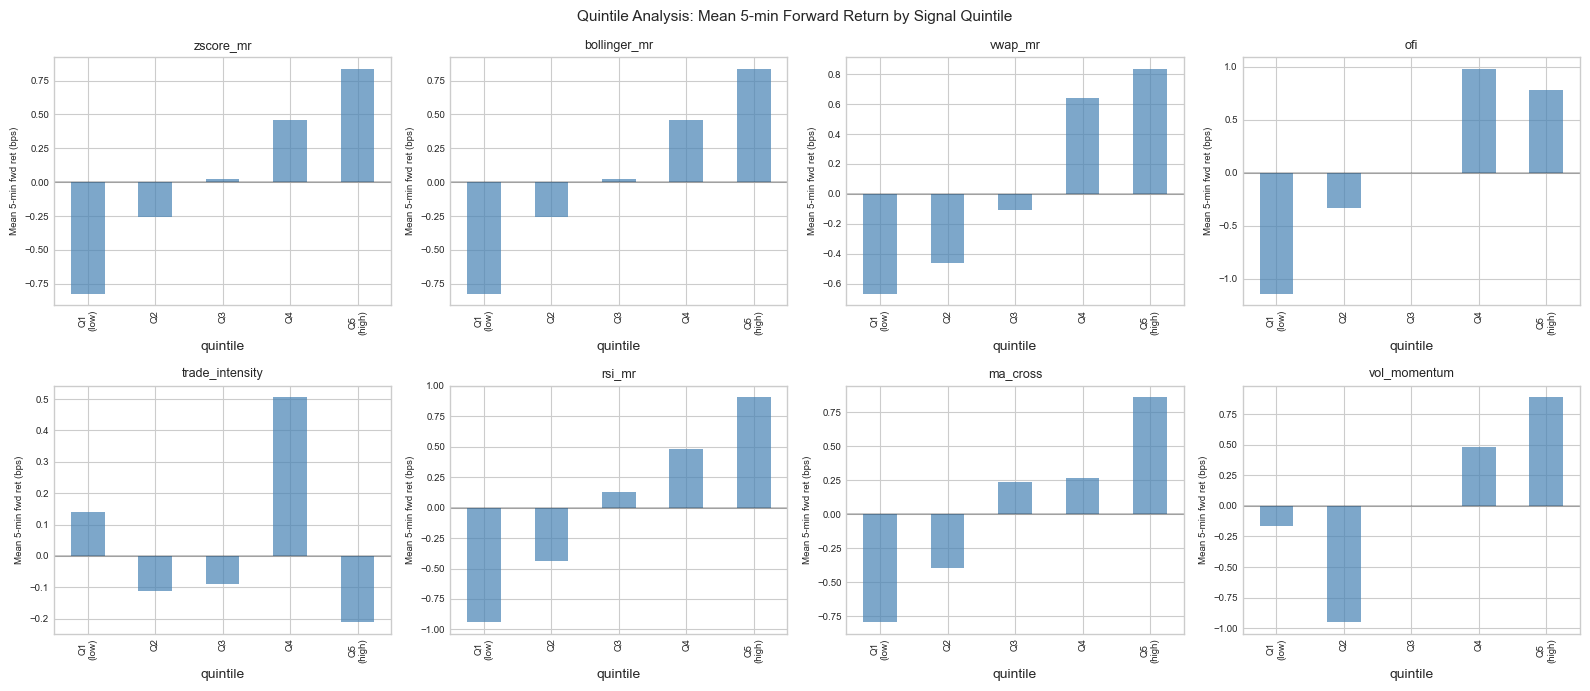

In [8]:
fwd_5m = bars['close'].pct_change(5).shift(-5)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, name in enumerate(signal_names):
    df_q = pd.DataFrame({'signal': all_signals[name], 'fwd': fwd_5m}).dropna()
    df_q['quintile'] = pd.qcut(df_q['signal'], 5, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
    means = df_q.groupby('quintile', observed=False)['fwd'].mean() * 10000  # in bps
    means.plot.bar(ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(name, fontsize=9)
    axes[i].set_ylabel('Mean 5-min fwd ret (bps)', fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].axhline(0, color='black', linewidth=0.3)

plt.suptitle('Quintile Analysis: Mean 5-min Forward Return by Signal Quintile', fontsize=11)
plt.tight_layout()
plt.show()

## 2.6 Composite Signal

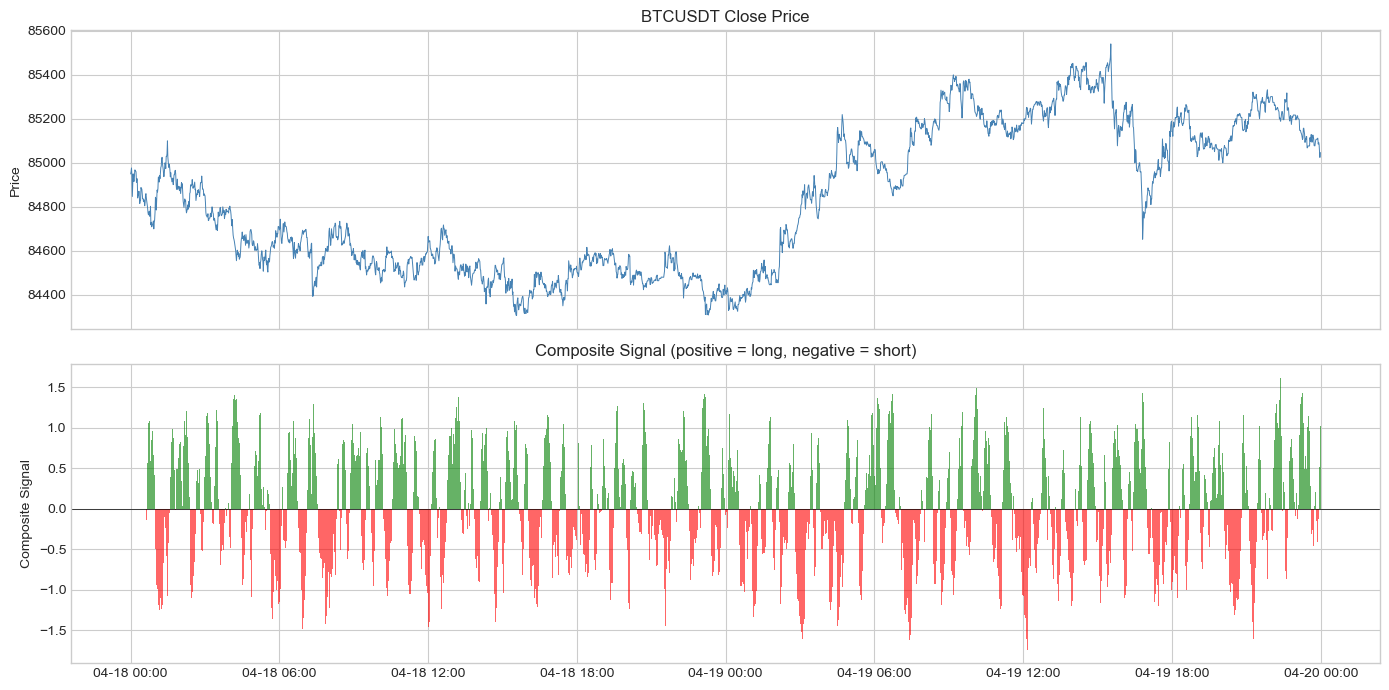

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(bars.index, bars['close'], linewidth=0.7, color='steelblue')
axes[0].set_ylabel('Price')
axes[0].set_title('BTCUSDT Close Price')

composite = all_signals['composite']
colors = np.where(composite > 0, 'green', 'red')
axes[1].bar(composite.index, composite.values, width=1/1440, color=colors, alpha=0.6)
axes[1].set_ylabel('Composite Signal')
axes[1].set_title('Composite Signal (positive = long, negative = short)')
axes[1].axhline(0, color='black', linewidth=0.5)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

In [10]:
# Composite signal IC
print("Composite Signal IC:")
for h in horizons:
    fwd_ret = bars['close'].pct_change(h).shift(-h)
    valid = pd.concat([composite.rename('signal'), fwd_ret.rename('fwd')], axis=1).dropna()
    ic = valid['signal'].corr(valid['fwd'], method='spearman')
    print(f"  {h:2d}-min horizon IC: {ic:.4f}")

Composite Signal IC:
   1-min horizon IC: 0.0627
   5-min horizon IC: 0.1046
  10-min horizon IC: 0.0988
  15-min horizon IC: 0.0793


## 2.7 Summary

Key findings from signal research:

1. **Mean-reversion signals** (z-score, Bollinger, VWAP, RSI) show the strongest predictive power at 5-15 min horizons, consistent with the negative autocorrelation observed in exploration.
2. **Order flow imbalance** adds orthogonal information — low correlation with price-based signals.
3. **Composite signal** achieves higher IC than any individual signal by diversifying across signal types.
4. **Quintile analysis** confirms monotonic relationship between signal strength and forward returns.

Next: backtest these signals with realistic transaction costs.